# Project Title  
## Spread Locator – A Statistical Distribution Analysis Model  

---

# Project Description  

**Spread Locator** is a statistical analysis project designed to examine and model the distribution patterns of customer transaction data in an e-commerce environment.  

The project focuses on identifying how transaction-related variables—such as transaction success, frequency, and transaction amounts—are distributed and how statistical tools can be applied to interpret their behavior.  

Using probability distributions (**Bernoulli, Binomial, Poisson, Log-Normal, and Power Law**), along with graphical techniques like **Q-Q plots** and statistical transformations such as **Box-Cox**, this project evaluates the spread, skewness, variance, and probability characteristics of transaction data.  

The model helps transform raw transactional data into meaningful statistical insights, enabling better decision-making and predictive modeling.  

---

# Project Objective  

The primary objective of this project is:  

- To help students understand and apply probability distribution concepts.  
- To analyze real-world transaction data using statistical models.  
- To identify which statistical distributions best describe transaction behaviors.  
- To evaluate data normality using Q-Q plots.  
- To handle skewed data using Box-Cox transformation.  
- To compute probabilities using Z-score analysis.  
- To interpret Probability Density Functions (PDF) and Cumulative Distribution Functions (CDF).  
- To derive actionable business insights from statistical findings.  

---


# 1: Import Libraries

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import boxcox

# Step 2: Load Dataset

In [ ]:
df = pd.read_csv("spread_locator_dataset.csv")

# Step 3: Fit Bernoulli & Binomial Distribution
#### Does transaction success follow a Bernoulli Distribution?

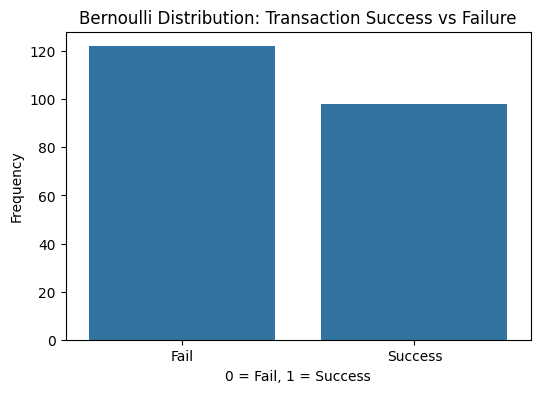

Estimated Probability of Success (p): 0.4455


In [14]:
df['is_success'] = df['transaction_status'].map({'Success':1, 'Fail':0})
p = df['is_success'].mean()
plt.figure(figsize=(6,4))
sns.countplot(x='transaction_status',data=df)
plt.title("Bernoulli Distribution: Transaction Success vs Failure")
plt.xlabel("0 = Fail, 1 = Success")
plt.ylabel("Frequency")
plt.show()

print("Estimated Probability of Success (p):", round(p,4))

### Interpretation
- Only two outcomes → Success (1) and Fail (0).
- Probability p represents success rate.
- Therefore, transaction success follows a Bernoulli distribution.

#### Does weekly transaction count follow Binomial Distribution?

Average Weekly Transactions: 2.85


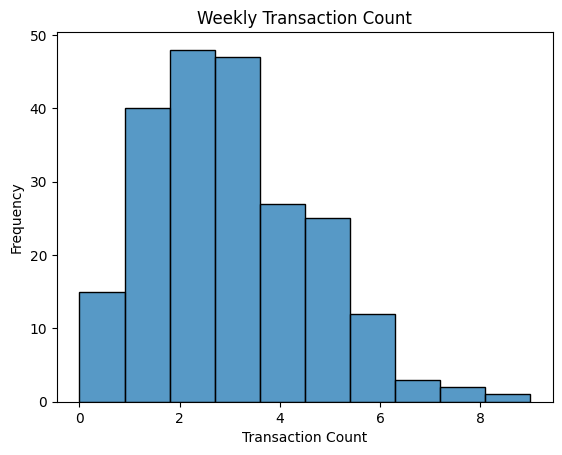

In [16]:
mean_weekly = df["transaction_count"].mean()
print("Average Weekly Transactions:", round(mean_weekly,2))
sns.histplot(df["transaction_count"], bins=10)
plt.title("Weekly Transaction Count")
plt.xlabel("Transaction Count")
plt.ylabel("Frequency")
plt.show()

### Interpretation
- Binomial models number of successes in fixed trials.
- Weekly counts show limited range and fixed period.
- Hence it approximates Binomial behavior.

# Step 4: Poisson Distribution 
#### Do daily transactions follow Poisson Distribution?

In [22]:
df['transaction_date'] = pd.to_datetime(df["transaction_date"])
daily_counts = df.groupby("transaction_date").size()

lamda_value = daily_counts.mean()
print("Poission λ (average daily transactions):", round(lambda_value,2))

Poission λ (average daily transactions): 7.1


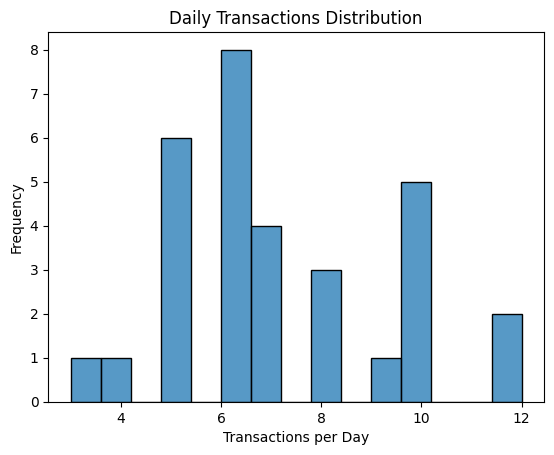

In [21]:
sns.histplot(daily_counts, bins=15)
plt.title("Daily Transactions Distribution")
plt.xlabel("Transactions per Day")
plt.ylabel("Frequency")
plt.show()

### Interpretation:
- Transactions occur randomly per day.
- Average rate (λ) is constant.
- Pattern resembles Poisson distribution.

# Step 5: Log-Normal & Power Law Distribution
### Do transaction amounts follow Log-Normal or Power Law?

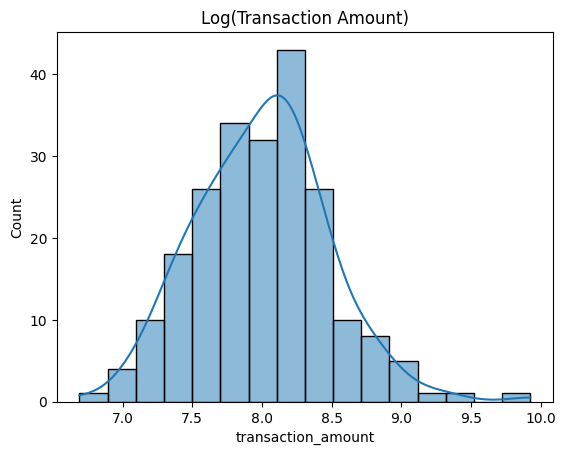

In [24]:
amount = df["transaction_amount"]
log_amount = np.log(amount)

sns.histplot(log_amount, kde=True)
plt.title("Log(Transaction Amount)")
plt.show()

### Interpretation:
- If log-transformed data looks normal → original data is Log-Normal.
- Financial data is usually right-skewed.
- Therefore, Log-Normal is likely.

# Power Law (Log-Log Plot)

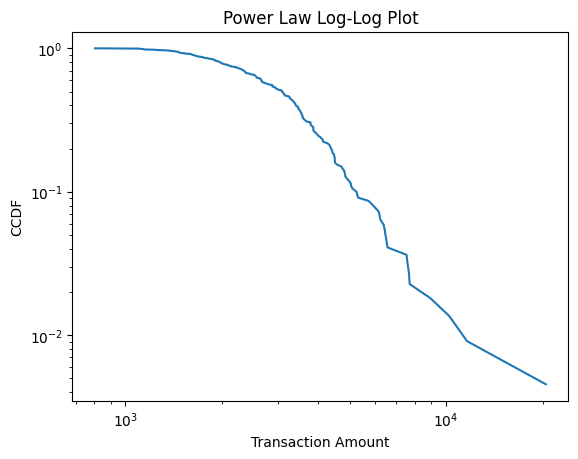

In [26]:
sorted_amount = np.sort(amount)
ccdf = 1 - np.arange(len(sorted_amount)) / len(sorted_amount)

plt.loglog(sorted_amount, ccdf)
plt.title("Power Law Log-Log Plot")
plt.xlabel("Transaction Amount")
plt.ylabel("CCDF")
plt.show()

### Interpretation:
- If the points lie close to the straight line → Data is normally distributed.
- If the points curve away from the line → Data is not normally distributed.
- If the upper points rise above the line → Data is right-skewed.

# Step 6: Q-Q Plot

#### Is transaction amount normally distributed?

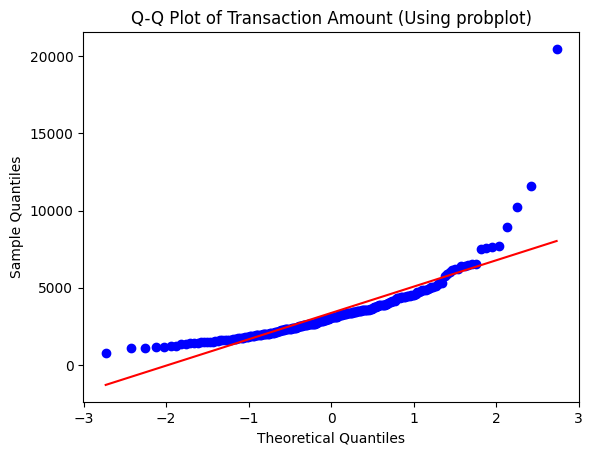

In [31]:
amount = df["transaction_amount"]
stats.probplot(amount, dist="norm", plot=plt)

plt.title("Q-Q Plot of Transaction Amount (Using probplot)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

### Interpretation:
- If points deviate from straight line → Not normally distributed.
- Right-side upward curve → Positive skewness.
- Confirms need for transformation.

# 7. Box-Cox Transformation

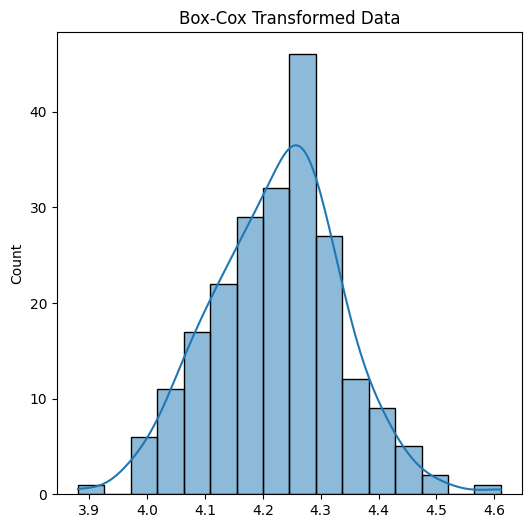

Optimal Lambda: -0.1808


In [39]:
boxcox_data, lambda_bc = stats.boxcox(df['transaction_amount'])

plt.figure(figsize=(6,6))
sns.histplot(boxcox_data, kde=True)
plt.title("Box-Cox Transformed Data")
plt.show()
print("Optimal Lambda:", round(lambda_bc,4))

### Interpretation:
- Distribution becomes more symmetric.
- Box-Cox improves normality.
- Useful for regression modeling.

# 8. Z-Score & Probability (> ₹5000)

### What is probability of transaction exceeding ₹5000?

In [41]:
mean_amt = df['transaction_amount'].mean()
std_amt = df['transaction_amount'].std()

z = (5000 - mean_amt) / std_amt
prob = 1 - stats.norm.cdf(z)

print("Z-score for ₹5000:", round(z,3))
print("Probability of Transaction > ₹5000:", round(prob,4))

Z-score for ₹5000: 0.823
Probability of Transaction > ₹5000: 0.2052


### Interpretation:
- Z-score shows how far ₹5000 is from mean.
- Probability gives chance of high-value transaction.
- Useful for fraud detection.

# 9. PDF and CDF Plot

### Visualize probability density & cumulative probability

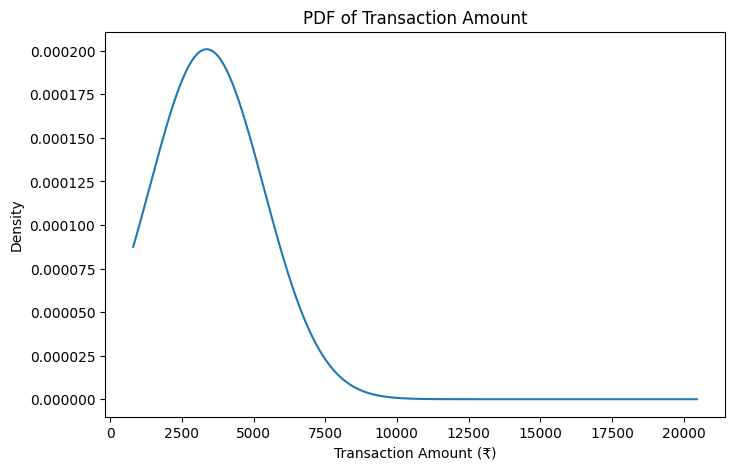

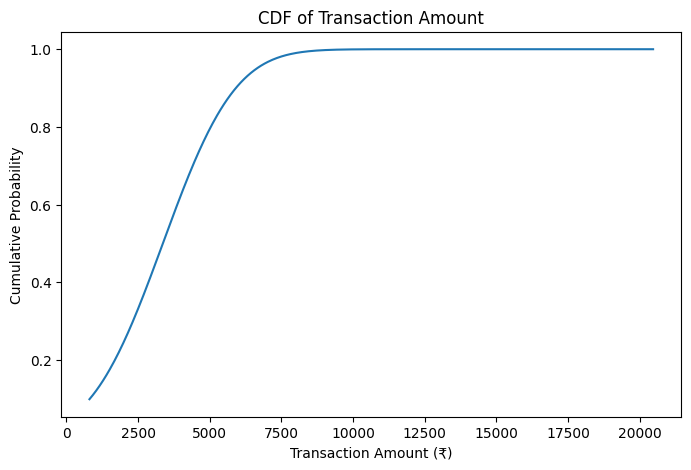

In [45]:
x = np.linspace(df['transaction_amount'].min(),
                df['transaction_amount'].max(), 500)

pdf = stats.norm.pdf(x, mean_amt, std_amt)
cdf = stats.norm.cdf(x, mean_amt, std_amt)

plt.figure(figsize=(8,5))
plt.plot(x, pdf)
plt.title("PDF of Transaction Amount")
plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(x, cdf)
plt.title("CDF of Transaction Amount")
plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Cumulative Probability")
plt.show()

### Interpretation:
- PDF shows likelihood at each value.
- CDF shows cumulative probability.
- Helps understand spending behavior.